In [47]:
import gymnasium as gym
import numpy as np 
import matplotlib.pyplot as plt
import random

Problem 1C

In [20]:
def fixed_policy(state):
    player_sum, dealer_card, usable_ace = state

    if player_sum >= 20:
        return 0
    
    else:
        return 1

In [21]:
def single_episode_prediction(env):
    episode = []

    state, info = env.reset()
    complete = False

    while not complete:
        action = fixed_policy(state)

        next_state, reward, terminated, truncated, info = env.step(action)

        episodes.append((state, reward))

        state = next_state

        if terminated is True or truncated is True:
            complete = True
             
    return episode


In [98]:
def first_visit_mc_prediciton(env, episodes, gama, const_alpha, a=.01):
    V = {}
    N = {}

    for eps in range(episodes):
        episode = single_episode(env)

        states = []
        rewards = []

        for each in episode:
            states.append(each[0])
            rewards.append(each[1])

        G = 0

        for t in reversed(range(len(episode))):
            state = states[t]
            reward = rewards[t]

            G = reward + gama * G

            if state not in states[:t]:
                if state not in V:
                    V[state] = 0
                    N[state] = 0
                    
                N[state] += 1

                if const_alpha:
                    alpha = a 
                
                else: 
                    alpha = (1 / N[state])

                V[state] = V[state] + alpha * (G - V[state])

    return V, N


In [95]:

def heat_map_grid(V, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    grid = np.zeros((len(player_sums), len(dealer_cards)))

    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (player_sum, dealer_card, usable_ace)
            grid[i, j] = V[state]

    return grid

In [96]:
def plot_heat_map(grid, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    plt.figure(figsize=(8, 6))
    plt.imshow(grid, origin="lower")
    plt.colorbar(label="V(s)")

    plt.xticks(ticks=np.arange(len(dealer_cards)), labels=dealer_cards)
    plt.yticks(ticks=np.arange(len(player_sums)), labels=player_sums)

    plt.xlabel("Dealer Card")
    plt.ylabel("Player Sums")

    plt.title(f"Usable ace: {usable_ace}")

    plt.show()


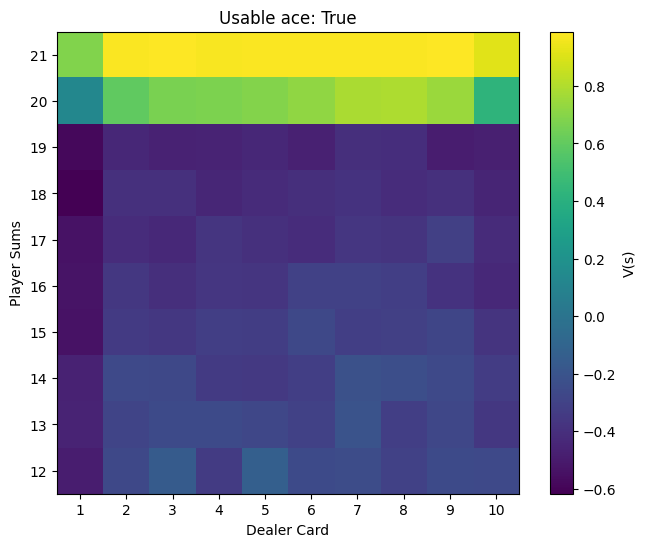

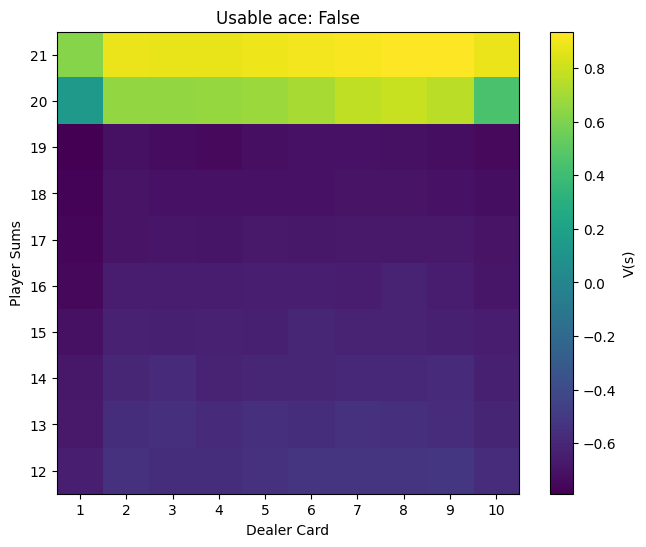

In [99]:
env = gym.make("Blackjack-v1", sab=True)

V, N = first_visit_mc_prediciton(env, 500000, 1, False)

env.close()

grid_usable_true = heat_map_grid(V, True)
grid_usable_false = heat_map_grid(V, False)

plot_heat_map(grid_usable_true, True)
plot_heat_map(grid_usable_false, False)




Problem 1D

In [81]:
def epsilon_soft_policy(state, Q, epsilon):
    actions = [0, 1]

    if random.random() < epsilon:
        return random.choice(actions)

    stay = Q.get((state, 0), 0)
    hit = Q.get((state, 0), 0)

    if stay > hit:
        return 0
    
    elif hit > stay:
        return 1

    else:
        return random.choice(actions)

In [82]:
def single_episode_control(env, Q, epsilon):
    episode = []

    state, info = env.reset()
    complete = False

    while not complete:
        action = epsilon_soft_policy(state, Q, epsilon)

        next_state, reward, terminated, truncated, info, =  env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated is True or truncated is True:
            complete = True

    return episode

In [61]:
def mc_control(env, episodes, gama, epsilon):
    Q = {}
    N = {}

    for eps in range(episodes):
        episode = single_episode_control(env, Q, epsilon)

        states = []
        actions = []
        rewards = []

        for state, action, reward in episode:
            states.append(state)
            actions.append(action)
            rewards.append(reward)

            G = 0

        for t in reversed(range(len(episode))):
            state = states[t]
            action = actions[t]
            reward = rewards[t]

            G = reward + gama * G

            state_action = (state, action)

            prev_state_actions = []

            for i in range(t):
                prev_state_actions.append((states[i], actions[i]))

            if state_action in prev_state_actions:
                if state_action not in Q:
                    Q[state_action] = 0
                    N[state_action] = 0

                N[state_action] += 1
                Q[state_action] = Q[state_action] + (1 / N[state_action]) * (G - Q[state_action])

    return Q, N

In [88]:
def greedy_action(state, Q):
    stay = Q.get((state, 0), 0)
    hit = Q.get((state, 1), 0)

    if stay > hit:
        return 0
        
    elif hit > stay:
        return 1

    else:
        return np.random.choice([0, 1])

In [84]:
def policy_grid(Q, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    grid = np.zeros((len(player_sums), len(dealer_cards)))

    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (int(player_sum), int(dealer_card), usable_ace)
            grid[i, j] = greedy_action(state, Q)

    return grid

In [78]:
def plot_policy(grid, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    plt.figure(figsize=(8, 6))
    plt.imshow(grid, origin="lower")

    plt.xticks(ticks=np.arange(len(dealer_cards)), labels= dealer_cards)
    plt.yticks(ticks=np.arange(len(player_sums)), labels= player_sums)
    plt.title(f"Usable Ace: {usable_ace}")

    plt.xlabel("Dealer Cards")
    plt.ylabel("Pplayer Sum")

    for i in range(len(player_sums)):
        for j in range(len(dealer_cards)):
            if grid[i, j] == 1:
                label = "H"
            
            else:
                label = "S"

            plt.text(j, i, label)

    plt.show()

In [72]:
def compare(Q, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    differnce = []

    for player_sum in player_sums:
        for dealer_card in dealer_cards:
            state = (player_sum, dealer_card, usable_ace)

            greedy = greedy_action(state, Q)
            fixed = fixed_policy(state)

            if greedy != fixed:
                differnce.append((state, greedy, fixed))

    return differnce

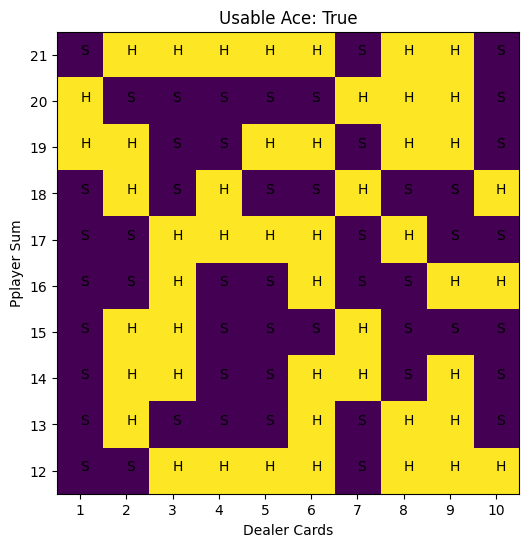

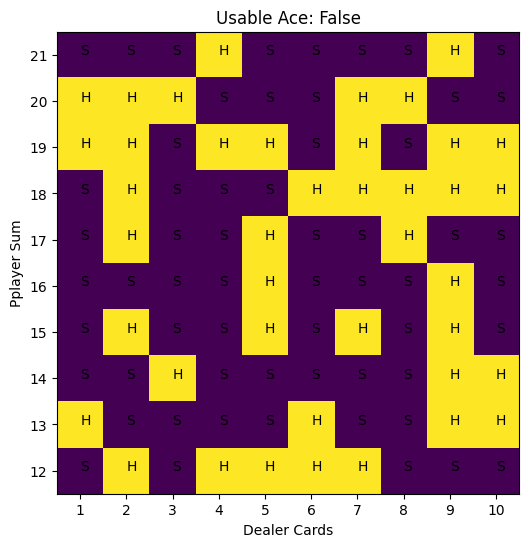

In [89]:
env = gym.make("Blackjack-v1", sab=True)

Q, N = mc_control(env, 500000, 1, 0.1)

env.close()

policy_grid_true = policy_grid(Q, True)
policy_grid_false = policy_grid(Q, False)

plot_policy(policy_grid_true, usable_ace=True)
plot_policy(policy_grid_false, usable_ace=False)

diff_true = compare(Q, True)
diff_false = compare(Q, False)

Problem 2C

In [ ]:
def single_episode(state, t_left, t_right):
    episode = []
    current_state = state

    while current_state != t_left and current_state != t_right:
        action = random.random.choice(([-1, 1]))
        next_state = state + action

        if next_state == t_right:
            reward = 1

        else:
            reward = 0

        episode.append((state, reward, next_state))
        current_state = next_state

    return episode

In [92]:
def rms_error(V, actual):
    estimated_values = V[1:6]
    squared_errors = (est_values - actual) ** 2
    mean_squared_error = np.mean(squared_errors)

    return np.sqrt(mean_squared_error)

In [106]:
def td_prediction(state, t_left, t_right, alpha, episodes):
    V = np.zeros(7)
    V[1:6] = 0.5
    rms_errors = []

    for ep in range(episodes):
        episode = single_episode(state, t_left, t_right)

        for state, reward, next_state in episode:
            td_target = reward + V[next_state]
            td_error = td_target - V[state]
            V[state] = V[state] + alpha * td_error

        rms_errors.append(rms_error(V))

    return V, rms_errors



In [104]:
def mc_prediction(state, t_left, t_right, alpha, episodes):
    V = np.zeros(7)
    V[1:6] = 0.5
    rms_errors = []

    for episode_num in range(episodes):
        episode = single_episode(state, t_left, t_right)
        G = episode[-1][1]
        visited_states = []

        for state, reward, next_state in episode:
            if state not in visited_states:
                mc_error = G - V[state]
                V[state] = V[state] + alpha * mc_error
                visited_states.append(state)

        rms_errors.append(rms_error(V))

    return V, rms_errors

In [110]:
t_left = 0
t_right = 6
start_state = 3
actual_vals = np.array([1/6, 2/6, 3/6, 4/6, 5/6])
alpha = .1
episodes = 100

td_V, td_errors = td_prediction(start_state, t_left, t_right, alpha, episodes)
mc_V, mc_errors = mc_prediction(start_state, t_left, t_right, alpha, episodes)

TypeError: single_episode() takes 1 positional argument but 3 were given